# Premier essaie de génération d'images

In [33]:
# Importation des différentes librairies utiles pour le notebook

# Sickit-learn met régulièrement à jour des versions et
# indique des futurs warnings. Ces lignes permettent de ne pas les afficher.
import warnings  # Permet de gérer les avertissements
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données en format tabulaire
from scipy.stats import randint  # Pour les distributions aléatoires
import numpy as np  # Calcul numérique
from numpy import mean, std  # Statistiques de base
import os  # Interaction avec le système d'exploitation
from os import listdir  # Liste les fichiers dans un répertoire
from os.path import isfile, join  # Fonctions pour gérer les chemins de fichiers
import sys  # Manipulation du système
import random  # Génération de nombres aléatoires
import cv2  # Librairie pour la vision par ordinateur
import zipfile  # Manipulation des archives ZIP

# Librairie d'affichage
import matplotlib.pyplot as plt  # Visualisation de données
from PIL import Image, ImageDraw  # Manipulation d'images avec Pillow

# Scikit-learn pour l'apprentissage automatique
from sklearn.decomposition import PCA  # Analyse en composantes principales(ACP)

# TensorFlow et Keras pour le deep learning
import tensorflow as tf  # Framework principal pour l'apprentissage profond
import keras  # API de haut niveau pour TensorFlow
from keras import layers  # Modules de construction de modèles Keras
from keras import models  # Définition et manipulation des modèles
from keras import optimizers  # Optimisateurs pour les modèles Keras
from keras.optimizers import Adam  # Optimiseur Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator  #Générateur

# Utilitaires Keras pour le traitement d'images
from keras.utils import img_to_array, load_img  # Conversion images en tableaux
from keras.callbacks import (ModelCheckpoint,
                             EarlyStopping)  # Gestion des checkpoints
from keras import backend as K  # Backend Keras pour opérations de bas niveau
from keras.models import Model, load_model  # Définition/chargement des modèles
from keras.layers import LeakyReLU  # Activation LeakyReLU
from keras.preprocessing import image  # Prétraitement des images

# Couches Keras pour les modèles convolutifs et autres
from keras.layers import (Input, Conv2D, Flatten, Dense, Conv2DTranspose,
                          Reshape, Activation,
                          BatchNormalization,
                          Dropout)  # Couches pour CNN et autoencoders
from keras.layers import (InputLayer, MaxPooling2D,
                          UpSampling2D)  # Couches supplémentaires pour les CNN



In [ ]:
# Datasets
from keras.datasets.mnist import load_data
# Scikitlearn
from sklearn.decomposition import PCA # Analyse en composantes principales (ACP)

In [72]:
# Définition du répertoire cible
model_dir = "./Data_humanface_cat_without_caption_1000/"

# Création du répertoire s'il n'existe pas
os.makedirs(model_dir, exist_ok=True)

zip_file = "Data_humanface_cat_without_caption_1000.zip"

!wget https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip


# Extraction du fichier ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(model_dir)

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)

--2026-05-01 23:12:48--  https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip
Resolving www.lirmm.fr (www.lirmm.fr)... 193.49.104.251
Connecting to www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42306490 (40M) [application/zip]
Saving to: ‘Data_humanface_cat_without_caption_1000.zip’

Data_humanface_cat_ 100%[===================>]  40.35M   736KB/s    in 33s     

2026-05-01 23:13:22 (1.23 MB/s) - ‘Data_humanface_cat_without_caption_1000.zip’ saved [42306490/42306490]



In [ ]:
##affichage des images 

Nombre d'images dans Data_humanface_cat_without_caption_1000/images/cat : 1000
Format (shape) des images : (256, 256, 3)


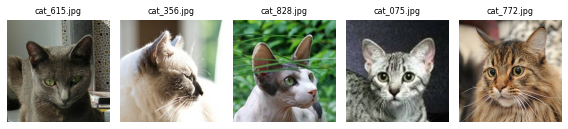

In [83]:
# Répertoire contenant les images
src_dir = "Data_humanface_cat_without_caption_1000/images"
image_dir = os.path.join(src_dir, "cat")

files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

print("Nombre d'images dans", image_dir, ":", len(files))

if files:
    with Image.open(os.path.join(image_dir, files[0])) as img:
        shape = img.size[::-1] + (3,)  # (height, width, 3)
        print("Format (shape) des images :", shape)


# Tirage de 5 images aléatoires
random_files = random.sample(files, 5)

# Affichage
plt.figure(figsize=(8, 2))
for i, fname in enumerate(random_files):
    img_path = os.path.join(image_dir, fname)
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=["cat"],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


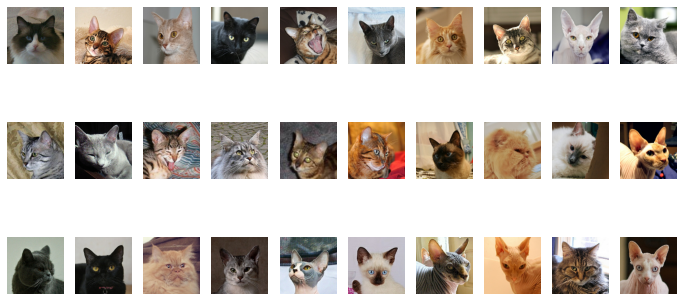

In [85]:
# Obtention du premier batch d'images générées
data_batch = next(data_flow)

# Affichage des 30 premières images du batch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 10, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(data_batch[0][i])
    ax.axis('off')
plt.show()

In [86]:
def build_encoder(input_dim, output_dim):
    tf.keras.backend.clear_session()

    encoder_input = Input(shape=input_dim, name='encoder_input')
    x = encoder_input

    x = Conv2D(32, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_1')(x)
    x = LeakyReLU(name='encoder_act_1')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_2')(x)
    x = LeakyReLU(name='encoder_act_2')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_3')(x)
    x = LeakyReLU(name='encoder_act_3')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_4')(x)
    x = LeakyReLU(name='encoder_act_4')(x)

    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten()(x)
    encoder_output = Dense(output_dim, name='encoder_output')(x)

    encoder = Model(encoder_input, encoder_output, name='encoder')
    return encoder_input, encoder_output, shape_before_flattening, encoder

In [87]:
# Création de l'encodeur avec les dimensions d'entrée et de sortie spécifiées
encoder_input, encoder_output, shape_before_flattening, encoder = build_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Affichage du résumé de l'encodeur
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,648 (3.48 MB)

 Trainable params: 912,648 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

In [88]:
def build_decoder(input_dim, shape_before_flattening):
    # Entrée du décodeur (vecteur latent)
    decoder_input = Input(shape=(input_dim,), name='decoder_input')

    # Projeter dans un tenseur de même forme qu'avant le Flatten de l'encodeur
    x = Dense(np.prod(shape_before_flattening))(decoder_input)
    x = Reshape(shape_before_flattening)(x)

    # Couches de déconvolution (effet miroir de l'encodeur)
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_1')(x)
    x = LeakyReLU(name='decoder_act_1')(x)

    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_2')(x)
    x = LeakyReLU(name='decoder_act_2')(x)

    x = Conv2DTranspose(32, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_3')(x)
    x = LeakyReLU(name='decoder_act_3')(x)

    x = Conv2DTranspose(3, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_4')(x)
    decoder_output = Activation('sigmoid', name='decoder_output')(x)

    decoder = Model(decoder_input, decoder_output, name='decoder')
    return decoder_input, decoder_output, decoder

In [14]:
def generate_from_random_latent(decoder, latent_shape=(7, 7, 8), n=10):
    """
    Tire au hasard n vecteurs latents et les passe dans le décodeur.

    Args:
        decoder: modèle Keras du décodeur.
        latent_shape: forme des vecteurs latents.
        n: nombre d'images à générer.
    """
    # Génération des vecteurs latents
    random_latents = np.random.normal(loc=0.0, scale=1.0,
                                      size=(n, *latent_shape))
    generated_images = decoder.predict(random_latents)

    # Mise en page cohérente : 5 colonnes par ligne
    n_cols = 5
    n_rows = (n // n_cols) + int(n % n_cols != 0)

    plt.figure(figsize=(n_cols * 4, n_rows * 2))
    for i in range(n):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(generated_images[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Images générées à partir de vecteurs latents aléatoires",
                 fontsize=16)
    plt.tight_layout()
    plt.show()

In [89]:
# Création du décodeur en utilisant la dimension de l'espace latent
# et le shape  avant le flattening
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │       823,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1                  │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2                  │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_3                  │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_3 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_4                  │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Activation)     │ (None, 128, 128, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,483 (3.50 MB)

 Trainable params: 916,483 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# L'entrée du modèle autoencodeur est celle de l'encodeur
autoencoder_input = encoder_input

# La sortie est obtenue en appliquant le décodeur à la sortie de l'encodeur
autoencoder_output = decoder(encoder_output)

# Création du modèle autoencodeur complet (encodeur + décodeur)
autoencoder = Model(autoencoder_input, autoencoder_output, name='autoencoder')

# Affichage de la structure du modèle
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       916,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829,131 (6.98 MB)

 Trainable params: 1,829,131 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [104]:
def train_autoencoder_from_generator(model, train_gen, val_gen,
                                     model_path, epochs=100, patience=5):
    """
    Entraîne un autoencodeur avec des générateurs Keras.

    Args:
        model         : modèle Keras compilé
        train_gen     : générateur d'entraînement
        val_gen       : générateur de validation
        model_path    : chemin de sauvegarde du meilleur modèle
        epochs        : nombre maximal d’époques
        patience      : patience pour EarlyStopping

    Returns:
        Le modèle avec les meilleurs poids restaurés.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=model_path,
                        monitor='val_loss',
                        save_best_only=True,
                        save_weights_only=False,
                        verbose=1)
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model

In [108]:
# Définition des hyperparamètres
epochs = 150
model_name = "catmodeltrain.keras"
model_path = os.path.join(model_dir, model_name)

# Compilation du modèle autoencodeur
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Générateur principal avec normalisation  et séparation train/validation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur pour les données d'entraînement
train_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # le sous-dossier contenant toutes les images
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input',
    subset='training'
)

# Générateur pour les données de validation
val_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=False,
    seed=42,
    class_mode='input',
    subset='validation'
)


# Entraînement du modèle autoencodeur
autoencoder = train_autoencoder_from_generator(
    model=autoencoder,
    train_gen=train_flow,
    val_gen=val_flow,
    model_path=model_path,
    epochs=epochs,
    patience=5
)

Found 800 images belonging to 1 classes.
Found 200 images belonging to 1 classes.
Epoch 1/150


E0000 00:00:1777672681.665284     982 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/autoencoder_1/encoder_act_1_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/autoencoder_1/encoder_conv_1_1/BiasAdd'.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 0.6931 
Epoch 1: val_loss improved from None to 0.69299, saving model to ./Data_humanface_cat_without_caption_1000/catmodeltrain.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 13s/step - loss: 0.6931 - val_loss: 0.6930
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.6929
Epoch 2: val_loss improved from 0.69299 to 0.69282, saving model to ./Data_humanface_cat_without_caption_1000/catmodeltrain.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.6929 - val_loss: 0.6928
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - loss: 0.6927
Epoch 3: val_loss improved from 0.69282 to 0.69263, saving model to ./Data_humanface_cat_without_caption_1000/catmodeltrain.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.6927 - val_loss: 0.6926
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - loss: 0.6925
Epoch 4: val_loss improved from 0.69263 to 0.69241, saving model to ./Data_humanface_cat_without_caption_1000/catmodeltrain.keras
2/2 ━━━━━━━━━━━━━━━━━━━━

In [109]:
def show_images(autoencoder, images=None):
    """
    Fonction pour afficher les images originales et leurs reconstructions générées par l'autoencodeur.

    Si aucun lot d'images n'est fourni, la fonction récupère un lot d'images depuis le générateur de données.

    Arguments :
    - autoencoder : L'autoencodeur entraîné, utilisé pour générer des reconstructions des images.
    - images (optionnel) : Un tableau d'images à afficher. Si non spécifié, un lot d'images est récupéré du générateur de données.

    Sortie :
    - Affichage des images originales et leurs reconstructions générées par l'autoencodeur.
    """

    if images is None:
        example_batch = next(data_flow)
        example_batch = example_batch[0]
        images = example_batch[:10]

    n_to_show = images.shape[0]

    # Génération des reconstructions des images
    reconst_images = autoencoder.predict(images)

    # Création de la figure pour l'affichage
    fig = plt.figure(figsize=(15, 3))
    fig.subplots_adjust(hspace=0.4, wspace=0.4)

    # Affichage des images originales
    for i in range(n_to_show):
        img = images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+1)
        sub.axis('off')
        sub.imshow(img)

    # Affichage des images reconstruites
    for i in range(n_to_show):
        img = reconst_images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+n_to_show+1)
        sub.axis('off')
        sub.imshow(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


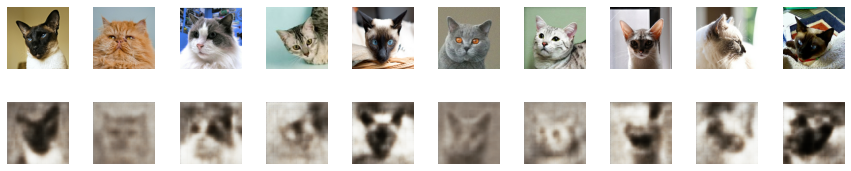

In [110]:
# Chemin vers le modèle entraîné
model_path = os.path.join(model_dir, "catmodeltrain.keras")

# Chargement du modèle
autoencoder = load_model(model_path)

# Récupère le premier lot d'images du générateur de données
example_batch = next(data_flow)

# Sélectionne uniquement les images du batch (le premier élément a les images)
example_batch = example_batch[0]

# Prend les 10 premières images du lot pour les afficher
example_images = example_batch[:10]

# Affiche les images originales et reconstruites par l'autoencodeur
show_images(autoencoder, example_images)